# 02 — Returns and Risk (Exploratory Data Analysis)

Phase 2 of the Indian Equity AI project plan.

For each of the 5 stocks:
1. Weekly / monthly returns (calendar-based, on top of Phase 1's 1d/5d/20d/60d trading-day returns)
2. Rolling volatility (already computed in Phase 1)
3. Drawdown (rolling + max)
4. Beta vs NIFTY 50
5. Correlation vs NIFTY 50, sector index, and other stocks in the universe

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import pandas as pd

from src.ingestion.market_data import download_index_ohlcv
from src.preprocessing.clean import clean_ohlcv, validate_ohlcv
from src.features.returns import add_returns
from src.features.risk import add_drawdown, max_drawdown, period_returns, beta, correlation_matrix

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
UNIVERSE = ["RELIANCE", "TCS", "INFY", "HDFCBANK", "ITC"]

SECTOR_INDEX = {
    "TCS": "^CNXIT",
    "INFY": "^CNXIT",
    "HDFCBANK": "^NSEBANK",
    # ITC (FMCG) and RELIANCE (conglomerate/energy) sector indices
    # have unreliable/near-empty history on Yahoo Finance -- see note below.
}

## Step 0: Load Phase 1 output

In [2]:
universe = pd.read_parquet(DATA_PROCESSED / "prices_daily.parquet")
assert validate_ohlcv(universe) == {
    "missing_values": 0,
    "duplicate_rows": 0,
    "non_positive_prices": 0,
    "negative_volume": 0,
    "high_below_low": 0,
}
universe.groupby("symbol")["date"].agg(["min", "max", "count"])

,min,max,count
symbol,,,
HDFCBANK,2021-09-27,2026-09-25,1241
INFY,2021-09-27,2026-09-25,1241
ITC,2021-09-27,2026-09-25,1241
RELIANCE,2021-09-27,2026-09-25,1241
TCS,2021-09-27,2026-09-25,1241


## Step 1: Weekly and monthly returns

In [3]:
weekly = period_returns(universe, freq="W-FRI")
monthly = period_returns(universe, freq="ME")

print("Weekly return summary (std dev by symbol):")
display(weekly.groupby("symbol")["return"].std())
print("Monthly return summary (std dev by symbol):")
display(monthly.groupby("symbol")["return"].std())

Weekly return summary (std dev by symbol):


symbol
HDFCBANK    0.027200
INFY        0.035619
ITC         0.028237
RELIANCE    0.029466
TCS         0.030924
Name: return, dtype: float64

Monthly return summary (std dev by symbol):


symbol
HDFCBANK    0.052490
INFY        0.074662
ITC         0.062190
RELIANCE    0.055771
TCS         0.065535
Name: return, dtype: float64

## Step 2: Drawdown

In [4]:
universe = add_drawdown(universe)
mdd = max_drawdown(universe)
print("Maximum drawdown per stock over the 5-year window:")
display(mdd.sort_values())

Maximum drawdown per stock over the 5-year window:


symbol
TCS        -0.564623
INFY       -0.507276
ITC        -0.492415
HDFCBANK   -0.321651
RELIANCE   -0.274221
Name: drawdown, dtype: float64

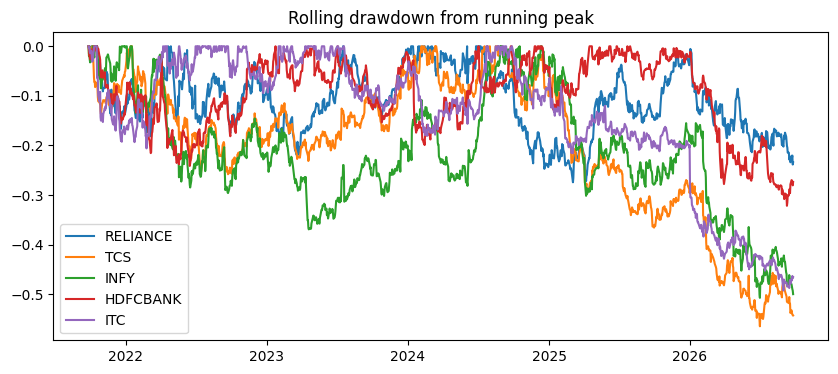

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
for symbol in UNIVERSE:
    subset = universe[universe["symbol"] == symbol].sort_values("date")
    ax.plot(subset["date"], subset["drawdown"], label=symbol)
ax.set_title("Rolling drawdown from running peak")
ax.legend()
plt.show()

## Step 3: Download NIFTY 50 and sector indices

In [6]:
nifty50 = clean_ohlcv(download_index_ohlcv("^NSEI", period="5y"))
nifty50 = add_returns(nifty50, periods=(1,))
print("NIFTY 50 rows:", len(nifty50))

sector_frames = {}
for sector_ticker in set(SECTOR_INDEX.values()):
    raw = download_index_ohlcv(sector_ticker, period="5y")
    if len(raw) < 250:  # need at least ~1 year of daily bars to be usable
        print(f"Skipping {sector_ticker}: only {len(raw)} rows returned by Yahoo Finance")
        continue
    cleaned = clean_ohlcv(raw)
    sector_frames[sector_ticker] = add_returns(cleaned, periods=(1,))
    print(sector_ticker, "rows:", len(cleaned))

NIFTY 50 rows: 1236
^CNXIT rows: 1235


^NSEBANK rows: 1235


**Note:** `^CNXFMCG` (ITC's sector) and `^CNXENERGY` (a proxy for RELIANCE) return almost no
historical data via Yahoo Finance's free chart API, so sector-relative correlation for
those two stocks is not available with this data source. NIFTY 50 correlation/beta and
cross-stock correlation are still computed for all 5 stocks.

## Step 4: Beta vs NIFTY 50

In [7]:
nifty_returns = nifty50.set_index("date")["return_1d"]

betas = {}
for symbol in UNIVERSE:
    stock = universe[universe["symbol"] == symbol].copy()
    stock = add_returns(stock, periods=(1,))
    stock_returns = stock.set_index("date")["return_1d"]
    betas[symbol] = beta(stock_returns, nifty_returns)

pd.Series(betas, name="beta_vs_nifty50")

RELIANCE    1.111226
TCS         0.812602
INFY        0.972032
HDFCBANK    1.064370
ITC         0.677879
Name: beta_vs_nifty50, dtype: float64

## Step 5: Correlation vs NIFTY 50, sector index, and other stocks

In [8]:
returns_wide = {}
for symbol in UNIVERSE:
    stock = universe[universe["symbol"] == symbol].copy()
    stock = add_returns(stock, periods=(1,))
    returns_wide[symbol] = stock.set_index("date")["return_1d"]

returns_wide["NIFTY50"] = nifty_returns
for sector_ticker, frame in sector_frames.items():
    returns_wide[sector_ticker] = frame.set_index("date")["return_1d"]

returns_wide_df = pd.DataFrame(returns_wide)
corr = correlation_matrix(returns_wide_df)
corr

,RELIANCE,TCS,INFY,HDFCBANK,ITC,NIFTY50,^CNXIT,^NSEBANK
RELIANCE,1.000000,0.265612,0.258777,0.368492,0.314748,0.687484,0.319619,0.503243
TCS,0.265612,1.000000,0.732320,0.232393,0.173979,0.495699,0.865147,0.275765
INFY,0.258777,0.732320,1.000000,0.256329,0.187088,0.514069,0.911372,0.285329
HDFCBANK,0.368492,0.232393,0.256329,1.000000,0.233112,0.698308,0.297118,0.776459
ITC,0.314748,0.173979,0.187088,0.233112,1.000000,0.462477,0.224860,0.346996
NIFTY50,0.687484,0.495699,0.514069,0.698308,0.462477,1.000000,0.597138,0.874170
^CNXIT,0.319619,0.865147,0.911372,0.297118,0.224860,0.597138,1.000000,0.348434
^NSEBANK,0.503243,0.275765,0.285329,0.776459,0.346996,0.874170,0.348434,1.000000


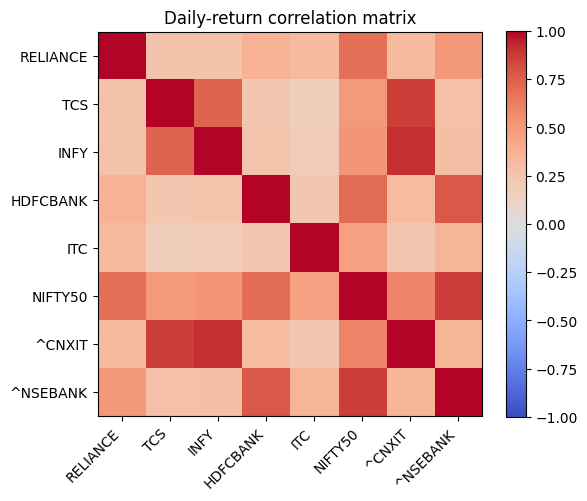

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
fig.colorbar(im)
ax.set_title("Daily-return correlation matrix")
plt.tight_layout()
plt.show()

## Summary: stock analytics report

In [10]:
report = pd.DataFrame({
    "max_drawdown": mdd,
    "beta_vs_nifty50": pd.Series(betas),
    "corr_vs_nifty50": corr.loc[UNIVERSE, "NIFTY50"],
})
report["weekly_return_std"] = weekly.groupby("symbol")["return"].std()
report["monthly_return_std"] = monthly.groupby("symbol")["return"].std()
report

,max_drawdown,beta_vs_nifty50,corr_vs_nifty50,weekly_return_std,monthly_return_std
HDFCBANK,-0.321651,1.064370,0.698308,0.027200,0.052490
INFY,-0.507276,0.972032,0.514069,0.035619,0.074662
ITC,-0.492415,0.677879,0.462477,0.028237,0.062190
RELIANCE,-0.274221,1.111226,0.687484,0.029466,0.055771
TCS,-0.564623,0.812602,0.495699,0.030924,0.065535


In [11]:
report.to_csv(DATA_PROCESSED / "stock_analytics_report.csv")
corr.to_csv(DATA_PROCESSED / "correlation_matrix.csv")
print("Saved:", DATA_PROCESSED / "stock_analytics_report.csv")
print("Saved:", DATA_PROCESSED / "correlation_matrix.csv")

Saved: D:\Practise\Stock Market Analysis\data\processed\stock_analytics_report.csv
Saved: D:\Practise\Stock Market Analysis\data\processed\correlation_matrix.csv
